## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [56]:
import numpy as np 
import fitsio as fio
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson
from scipy.interpolate import RegularGridInterpolator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [140]:
importlib.reload(inference)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'current2' / f'auto_{desc}_HSC', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'current2' / f'auto_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'current2' / f'cross_{desc}',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [59]:
## get sigmaj corrections
sims = False
if sims:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/v5/hscy3_sim_v5.fits')[1]
    zcat = catalog['Z'].read()
else:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits')[1]
    zcat = catalog['dnnz_photoz_best'].read()

/tmp/ipykernel_778070/2779201722.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


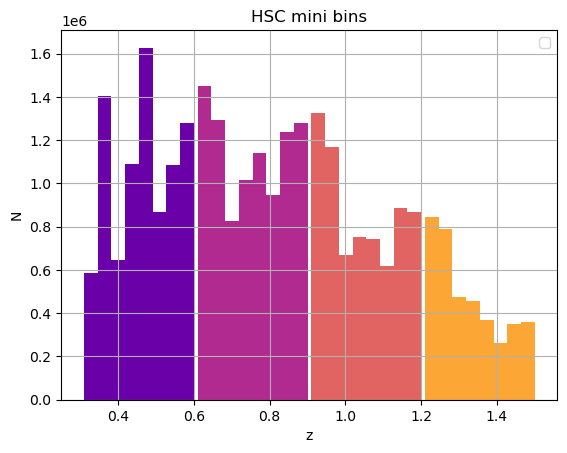

In [60]:
# hsc mini bins
mini_hsc = cf.CorrFileReader(path_dictionary['HSC']).get_bins('HSC')
colormap = plt.get_cmap('plasma')
# get sigmaj for two adjacents bins (std of redshift distribution in the bin ...)
sigmaj_corr = []
zmid = []
for i in range(1, len(mini_hsc)):
    z_bin = zcat[(zcat > mini_hsc[i-1]) & (zcat <= mini_hsc[i])]
    zmid.append(np.mean(z_bin))
    # careful : it's 1/std of the redshift distribution in the bin
    sigmaj_corr.append(np.std(z_bin))
    plt.hist(
        z_bin, 
        bins=int(40/len(mini_hsc)), 
        color=colormap(i/len(mini_hsc)),
        )
plt.xlabel('z')
plt.ylabel('N')
plt.title('HSC mini bins')
plt.grid()
plt.legend()

In [70]:
file = cf.CorrFileReader(path_dictionary['DESI_NGC']).get_file(1, 1, 'LRG', 'LRG', moc=1)
tpcf = TwoPointEstimator.load(file)

In [72]:
tpcf.cov()

AttributeError: Attribute cov does not exist

In [141]:
importlib.reload(inference)
importlib.reload(comb)
tracer = 'ELGnotqso'
nz = []
for i in range(1, 5):
    kwargs = {
        'path_dictionary' : path_dictionary,
        'scale_cuts' : [0.5, 3.0],
        'tracer' : tracer,
        'tomo_bin' : i,
        'sigmaj_corrections' : np.ones_like(sigmaj_corr),
        'verbose' : True,
    }
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    nz.append(
        inference.full_npz_tomo(
            **kwargs
            )
    )

Computing n(z) for tracer ELGnotqso and tomo bin 1
wss : bin_index1,2 : 1, 1, zloc1,2 : 0.8400000000000001, 1:0.8400000000000001, 2:0.8400000000000001
wsp : bin_index : 1, zloc : 0.8400000000000001
wss : bin_index1,2 : 2, 2, zloc1,2 : 0.9199999999999999, 1:0.9199999999999999, 2:0.9199999999999999
wsp : bin_index : 2, zloc : 0.9199999999999999
wss : bin_index1,2 : 3, 3, zloc1,2 : 1.0, 1:1.0, 2:1.0
wsp : bin_index : 3, zloc : 1.0
wss : bin_index1,2 : 4, 4, zloc1,2 : 1.08, 1:1.08, 2:1.08
wsp : bin_index : 4, zloc : 1.08
wss : bin_index1,2 : 5, 5, zloc1,2 : 1.1599999999999997, 1:1.1599999999999997, 2:1.1599999999999997
wsp : bin_index : 5, zloc : 1.1599999999999997
wss : bin_index1,2 : 6, 6, zloc1,2 : 1.2399999999999998, 1:1.2399999999999998, 2:1.2399999999999998
wsp : bin_index : 6, zloc : 1.2399999999999998
wss : bin_index1,2 : 7, 7, zloc1,2 : 1.3199999999999998, 1:1.3199999999999998, 2:1.3199999999999998
wsp : bin_index : 7, zloc : 1.3199999999999998
wss : bin_index1,2 : 8, 8, zloc1,2 :

(-2.0, 5.0)

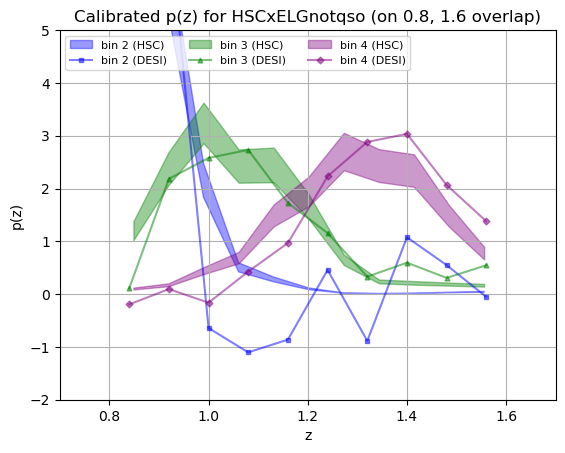

In [142]:
bins_tracer = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
bins_hsc = np.arange(0.3, 1.8, 0.3)
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]

for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)
ncurves = 0
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    plt.plot(
        zval, 
        nz[i]/simpson(nz[i], x=zval), 
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)'
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=ncurves, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
plt.ylim(-2, 5)

In [143]:
importlib.reload(inference)
data = []
# wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
for i in range(1, 5):
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    data.append(
        inference.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=[0.5, 5.0],
            tracer=tracer,
            tomo_bin=i,
            verbose=True,
            return_chunks=True,
            rebin=2,
            sigmaj_corrections=np.ones_like(sigmaj_corr),
            )
    )

Computing n(z) for tracer ELGnotqso and tomo bin 1
wss : bin_index1,2 : 1, 1, zloc1,2 : 0.8400000000000001, 1:0.8400000000000001, 2:0.8400000000000001
wsp : bin_index : 1, zloc : 0.8400000000000001
wss : bin_index1,2 : 2, 2, zloc1,2 : 0.9199999999999999, 1:0.9199999999999999, 2:0.9199999999999999
wsp : bin_index : 2, zloc : 0.9199999999999999
wss : bin_index1,2 : 3, 3, zloc1,2 : 1.0, 1:1.0, 2:1.0
wsp : bin_index : 3, zloc : 1.0
wss : bin_index1,2 : 4, 4, zloc1,2 : 1.08, 1:1.08, 2:1.08
wsp : bin_index : 4, zloc : 1.08
wss : bin_index1,2 : 5, 5, zloc1,2 : 1.1599999999999997, 1:1.1599999999999997, 2:1.1599999999999997
wsp : bin_index : 5, zloc : 1.1599999999999997
wss : bin_index1,2 : 6, 6, zloc1,2 : 1.2399999999999998, 1:1.2399999999999998, 2:1.2399999999999998
wsp : bin_index : 6, zloc : 1.2399999999999998
wss : bin_index1,2 : 7, 7, zloc1,2 : 1.3199999999999998, 1:1.3199999999999998, 2:1.3199999999999998
wsp : bin_index : 7, zloc : 1.3199999999999998
wss : bin_index1,2 : 8, 8, zloc1,2 :

Text(0, 0.5, 'w')

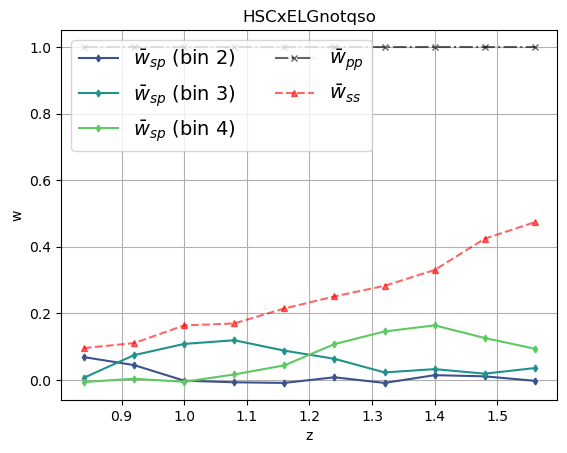

In [145]:
#wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
cmap = plt.get_cmap('viridis')
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    plt.plot(
        zval, 
        data[i][:, 0], 
        label=r'$\bar{w}_{sp}$' + f' (bin {i+1})', 
        color=cmap(i/4),
        marker='d',
        markersize=3.5,
        )
#plt.plot(
#    zval, 
#    inference.desi_bias_evolution(zval, tracer=tracer), 
#    label='DESI bias model', 
#    color='red', 
#    alpha=1, 
#    linestyle='-'
#    )
plt.plot(
    zval, 
    data[i][:, 2], 
    label=r'$\bar{w}_{pp}$', 
    color='black', 
    alpha=0.6, 
    linestyle='-.', 
    marker='x', 
    markersize=4
    ) 
plt.plot(
    zval, 
    data[i][:, 4], 
    label=r'$\bar{w}_{ss}$', 
    color='red', 
    alpha=0.6, 
    linestyle='--', 
    markersize=4, 
    marker='^'
    )

plt.grid()
plt.legend(loc='upper left', fontsize=14, ncol=2)
plt.title(f'HSCx{tracer}')
plt.xlabel('z')
plt.ylabel('w')

Text(0.5, 1.0, 'Bias models as a function of redshift for tracers')

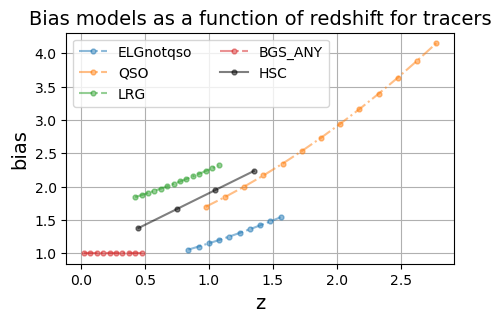

In [146]:
# plot the bias used
importlib.reload(inference)
plt.figure(figsize=(5, 3))
for tracer in ['ELGnotqso', 'QSO', 'LRG', 'BGS_ANY']:
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
    mids_tracer = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bias = inference.desi_bias_evolution(z=mids_tracer, tracer=tracer)
    plt.plot(
        mids_tracer, 
        bias, 
        marker='o', 
        markersize=3.5, 
        linestyle='-.',  
        alpha=0.5,
        label=f'{tracer}'
    )
mids_hsc = bins_hsc[:-1] + np.diff(bins_hsc) / 2
plt.plot(
    mids_hsc,
    inference.hsc_bias_evolution(z=mids_hsc, b=0.95),
    marker='o',
    markersize=3.5,
    linestyle='-',
    alpha=0.5,
    label='HSC',
    color='black'
)
plt.xlabel('z', fontsize=14)
plt.ylabel('bias', fontsize=14)
plt.grid()
plt.legend(ncols=2, loc='upper left', fontsize=10)
plt.title(f'Bias models as a function of redshift for tracers',  fontsize=14)

Tracer BGS_ANY
Computing n(z) for tracer BGS_ANY and tomo bin 1
wss : bin_index1,2 : 1, 1, zloc1,2 : 0.025, 1:0.025, 2:0.025
wsp : bin_index : 1, zloc : 0.025
wss : bin_index1,2 : 2, 2, zloc1,2 : 0.07500000000000001, 1:0.07500000000000001, 2:0.07500000000000001
wsp : bin_index : 2, zloc : 0.07500000000000001
wss : bin_index1,2 : 3, 3, zloc1,2 : 0.125, 1:0.125, 2:0.125
wsp : bin_index : 3, zloc : 0.125
wss : bin_index1,2 : 4, 4, zloc1,2 : 0.17500000000000002, 1:0.17500000000000002, 2:0.17500000000000002
wsp : bin_index : 4, zloc : 0.17500000000000002
wss : bin_index1,2 : 5, 5, zloc1,2 : 0.225, 1:0.225, 2:0.225
wsp : bin_index : 5, zloc : 0.225
wss : bin_index1,2 : 6, 6, zloc1,2 : 0.275, 1:0.275, 2:0.275
wsp : bin_index : 6, zloc : 0.275
wss : bin_index1,2 : 7, 7, zloc1,2 : 0.32500000000000007, 1:0.32500000000000007, 2:0.32500000000000007
wsp : bin_index : 7, zloc : 0.32500000000000007
wss : bin_index1,2 : 8, 8, zloc1,2 : 0.375, 1:0.375, 2:0.375
wsp : bin_index : 8, zloc : 0.375
wss : bi

Text(0.5, 0.98, 'Calibrated p(z) for HSC\nroot : outputs')

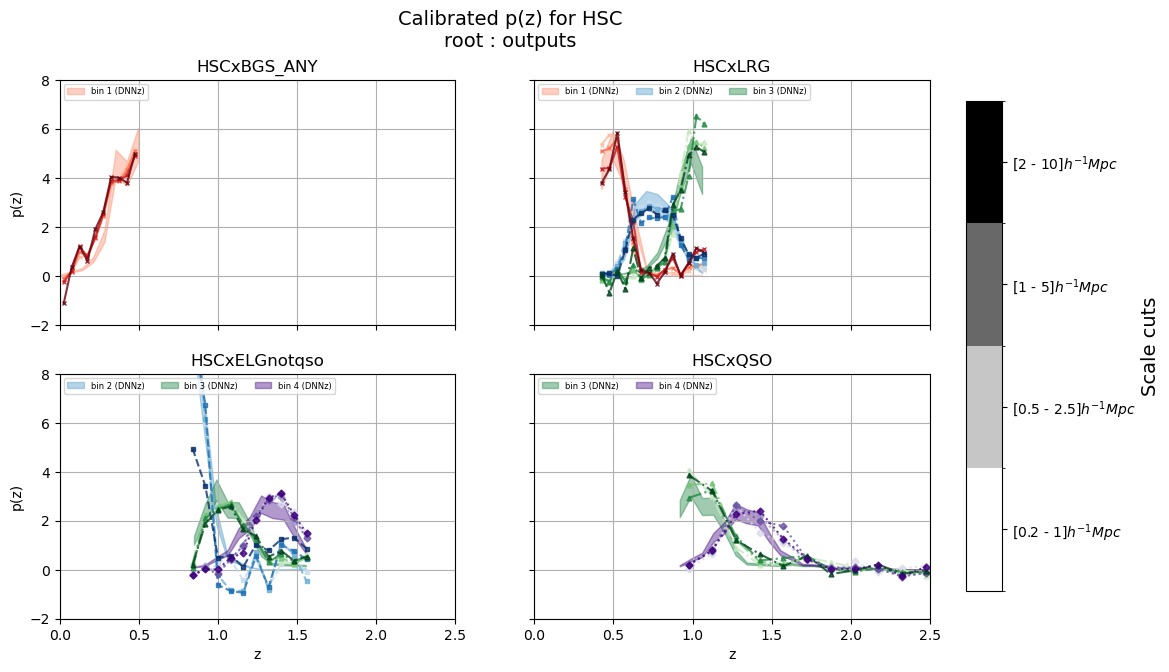

In [147]:
importlib.reload(inference)
scale_cuts = [[0.2, 1], [0.5, 2.5], [1, 5], [2, 10]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.subplots_adjust(right=0.85) 
axs = axs.flatten()

for n in range(len(tracers)):
    t = tracers[n]
    ax = axs[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    for k, sc in enumerate(scale_cuts):

        ids_to_skip = []
        nz = []

        for tomo in range(1, 5):
            print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
            nz.append(
                inference.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    scale_cuts=sc,
                    tracer=t,
                    tomo_bin=tomo,
                    sigmaj_corrections=np.ones_like(sigmaj_corr),
                    rebin=2,
                    )
            )

        for j in range(4):
            if max(range_tracer[0], bins_hsc[j]) > min(range_tracer[1], bins_hsc[j+1]):
                ids_to_skip.append(j)
                continue
            ncurves = 0
            ax.plot(
                zval, 
                nz[j]/simpson(nz[j], x=zval), 
                marker=markers[j], 
                linestyle=linestyles[j],
                markersize=3.5,   
                alpha=0.8,
                color=colormaps[j]((k+1)/4),
                )

    for m in range(4):
        if m not in ids_to_skip:
            ncurves += 1

            dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[mask, m+1], mids)

            ax.fill_between(
                mids, 
                np.percentile(dnnz, 16, axis=0), 
                np.percentile(dnnz, 84, axis=0), 
                color=colormaps[m]((m+2)/5), 
                label=f'bin {m+1} (DNNz)',
                alpha=0.4
                )
    if n == 2 or n == 3: 
        ax.set_xlabel('z')
    if n == 0 or n == 2:
        ax.set_ylabel('p(z)')
    ax.grid()
    ax.legend(fontsize=6, ncols=4, loc='upper left')
    ax.set_title(f'HSCx{t}')
    #ax.set_xlim(min(bins_tracer)-0.05, max(bins_tracer)+0.05)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-2, 8)

cmap = plt.cm.Greys
scale_levels = np.arange(0, len(scale_cuts)+1, 1)
norm = BoundaryNorm(boundaries=scale_levels, ncolors=cmap.N, extend='neither')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
scale_ticks = scale_levels[:-1] + 0.5
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=scale_ticks)
cbar.set_ticklabels([f'[{sc[0]} - {sc[1]}]' + r'$h^{-1}Mpc$' for sc in scale_cuts])
cbar.set_label('Scale cuts', fontsize=14)

fig.suptitle(f'Calibrated p(z) for HSC\nroot : {ROOT.name}', fontsize=14)

Combining results

Tracer BGS_ANY
Computing n(z) for tracer BGS_ANY and tomo bin 1
wss : bin_index1,2 : 1, 1, zloc1,2 : 0.025, 1:0.025, 2:0.025
wsp : bin_index : 1, zloc : 0.025
wss : bin_index1,2 : 2, 2, zloc1,2 : 0.07500000000000001, 1:0.07500000000000001, 2:0.07500000000000001
wsp : bin_index : 2, zloc : 0.07500000000000001
wss : bin_index1,2 : 3, 3, zloc1,2 : 0.125, 1:0.125, 2:0.125
wsp : bin_index : 3, zloc : 0.125
wss : bin_index1,2 : 4, 4, zloc1,2 : 0.17500000000000002, 1:0.17500000000000002, 2:0.17500000000000002
wsp : bin_index : 4, zloc : 0.17500000000000002
wss : bin_index1,2 : 5, 5, zloc1,2 : 0.225, 1:0.225, 2:0.225
wsp : bin_index : 5, zloc : 0.225
wss : bin_index1,2 : 6, 6, zloc1,2 : 0.275, 1:0.275, 2:0.275
wsp : bin_index : 6, zloc : 0.275
wss : bin_index1,2 : 7, 7, zloc1,2 : 0.32500000000000007, 1:0.32500000000000007, 2:0.32500000000000007
wsp : bin_index : 7, zloc : 0.32500000000000007
wss : bin_index1,2 : 8, 8, zloc1,2 : 0.375, 1:0.375, 2:0.375
wsp : bin_index : 8, zloc : 0.375
wss : bi

(-2.0, 5.0)

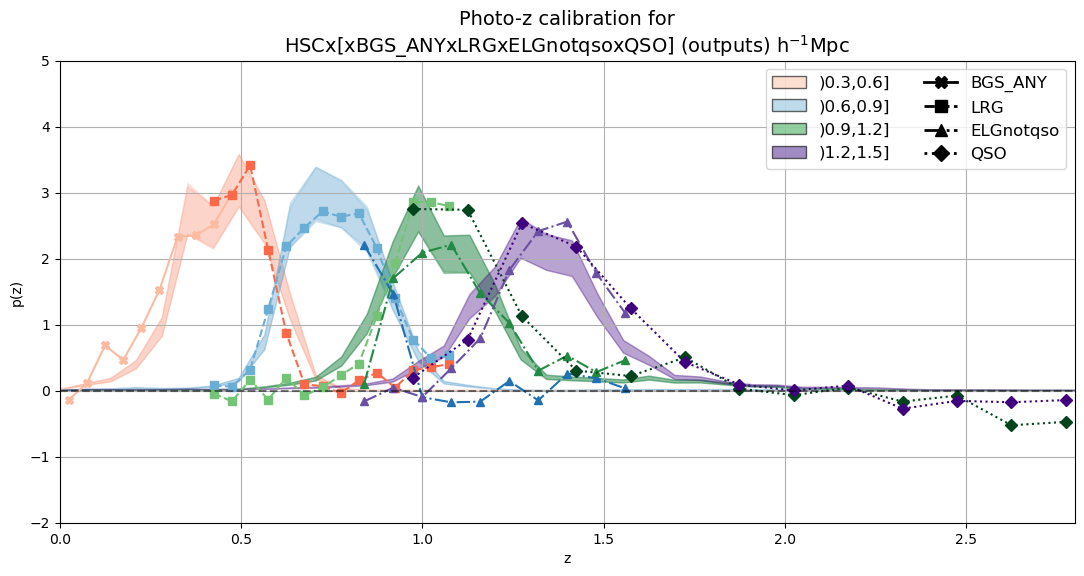

In [153]:
importlib.reload(inference)
ncurves = 0
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO']#'ELGnotqso', 'QSO']

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(right=0.85) 

scale_cuts = [[0.5, 5]] #[[0.2, 2.5], [0.2, 2.5], [0.2, 5], [0.5, 5]]
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[:, 0]
    mask_mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []

    for tomo in range(1, 5):
        print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
        nz.append(
            inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                scale_cuts=scale_cuts[n],
                tracer=t,
                tomo_bin=tomo,
                #verbose=True,
                sigmaj_corrections=np.ones_like(sigmaj_corr),
                rebin=1,
                )
            )
        
    area_ratio = []

    for outlier_idx in range(4):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
        area_ratio.append(simpson(np.percentile(dnnz, 50, axis=0)[mask], x=mask_mids))

        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for j in range(4):
        if j in ids_to_skip and tracer == 'QSO':
            continue
        ax.plot(
            zval, 
            nz[j]/simpson(nz[j], x=zval)*area_ratio[j], 
            marker=markers[n], 
            linestyle=linestyles[n],
            markersize=6,   
            alpha=1,
            color=colormaps[j]((n+1)/4),
            )
        
    title+= f'x{tracers[n]}'
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in range(1, len(bins_hsc)):
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer, 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=12,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-2, 5)

## $r_{cc}$ analysis on simulations

------------------------------------

In [134]:
importlib.reload(inference)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'sims' / f'auto_{desc}', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'sims' / f'auto_{desc}',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'sims' / f'cross_{desc}',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."
        
def rebin_edges(edges, factor=2):
    num_bins = len(edges) - 1
    num_new_bins = num_bins // factor
    new_edges = edges[::factor]

    # Include the last edge of the last full bin
    if len(new_edges) != num_new_bins + 1:
        new_edges = np.append(new_edges, edges[factor * num_new_bins])

    return new_edges

In [135]:
importlib.reload(inference)
scale_cuts = [0.01, 20]
tracer_rcc1 = 'LRG'
tracer_rcc2 = 'HSC'
rebin = 2
frcc = inference.full_rcc(
    path_dictionary=path_dictionary,
    tracer1=tracer_rcc1,
    tracer2=tracer_rcc2,
    scale_cuts=scale_cuts,
    rebin=rebin
    )

tracer1_redshift : [0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05
 1.1 ]
tracer2_redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]
tracer1_redshift : [0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05
 1.1 ], tracer1_bins : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 14 14 14 14 14 14 14 14 14 14
 14 14 14 14 14 14 14 14]
tracer2_redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ], tracer2_bins : [ 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
wpp : bin_index : 9, zloc : 0.42500000000000004
wss : bin_index1,2 : 1, 1, zloc1,2 : 0.42500000000000004, 1:0.42500000000000004, 2:0.42500000000000004
wsp : bin_index : 1, 

rp_sep : [ 0.08        0.13895814  0.24136705  0.41924896  0.72822568  1.26491106
  2.19712109  3.81634821  6.62890803 11.51425902 20.        ]
bins_t1 : [0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05
 1.1 ]
bins_t2 : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]
zval : [0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]


Text(0.5, 1.0, '$r_{cc}$ for LRGxHSC')

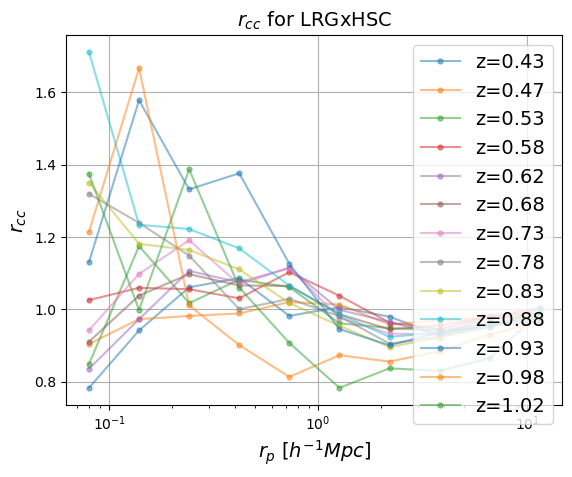

In [136]:
reader = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    )
rp_sep = rebin_edges(reader.get_bins('rp'), factor=rebin)
print(f"rp_sep : {rp_sep}")

bins_t1 = np.array(reader.get_bins(tracer_rcc1))
bins_t2 = np.array(reader.get_bins(tracer_rcc2))
print(f"bins_t1 : {bins_t1}")
print(f"bins_t2 : {bins_t2}")

zval_bins = []
for val in bins_t2:
    if np.any(np.isclose(val, bins_t1, atol=0.02)):
        zval_bins.append(val)
zval = zval_bins[:-1] + np.diff(zval_bins) / 2
print(f"zval : {zval}")

for i, r in enumerate(frcc):
    #scale = ct.arcsec2hMpc(sep*3600, zval[i])
    ## for now at LRG redshifts these are the same since minimum scale is > 0.1
    scale = rp_sep[:len(r)]
    plt.plot(scale, r, marker='o', markersize=3.5, linestyle='-', alpha=0.5, label=f'z={zval[i]:.2f}')
plt.xscale('log')
plt.xlabel(r'$r_p$ [$h^{-1}Mpc$]', fontsize=14)
plt.ylabel(r'$r_{cc}$', fontsize=14)
plt.grid()
plt.legend(loc='upper right', fontsize=14)
plt.title(r'$r_{cc}$' + f' for {tracer_rcc1}x{tracer_rcc2}', fontsize=14)

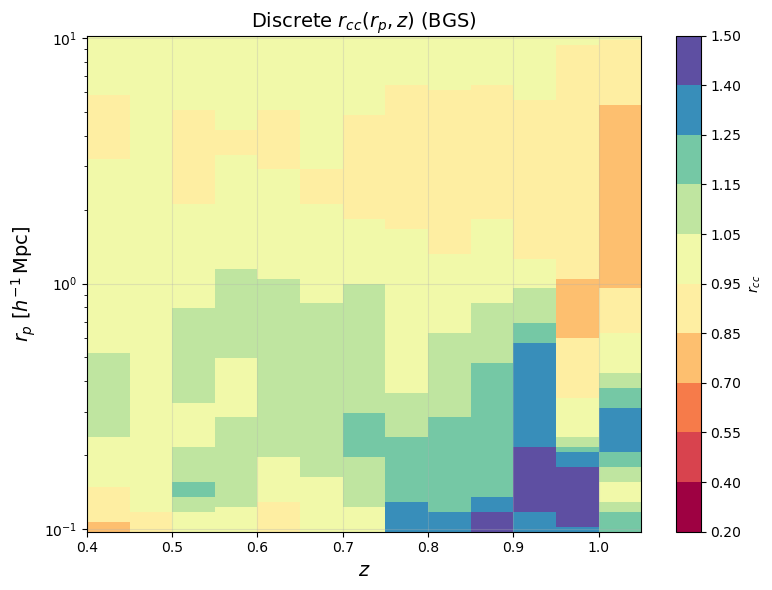

In [137]:
rcc_interp = []
scale_matrix = []

common_scale = np.logspace(-1, 1, 100)  # 0.1 to 10 h⁻¹Mpc (adjust as needed)

for i, r in enumerate(frcc):
    interp = interp1d(scale, r, bounds_error=False, fill_value=np.nan)
    rcc_interp.append(interp(common_scale))

# rcc_interp: shape (n_z, n_common_scale)
# Interpolator expects (z, rp_sep) in order, so we flip axes
rcc_interp_func = RegularGridInterpolator(
    (zval[:len(frcc)], common_scale),
    rcc_interp,
    bounds_error=False,
    fill_value=np.nan
)

rcc_interp = np.array(rcc_interp)  # shape (n_z, n_common_scale)
Z, R = np.meshgrid(zval[:len(frcc)], common_scale)

# Step 2: Discrete levels and colormap
levels = [0.2, 0.4, 0.55, 0.7, 0.85, 0.95, 1.05, 1.15, 1.25, 1.4, 1.5]  # 5 intervals = 6 boundaries
cmap = plt.get_cmap('Spectral', len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# Step 3: Plot
plt.figure(figsize=(8, 6))
pc = plt.pcolormesh(Z, R, rcc_interp.T, cmap=cmap, norm=norm, shading='auto')
plt.yscale('log')
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$r_p$ [$h^{-1}\,\mathrm{Mpc}$]', fontsize=14)
plt.title(r'Discrete $r_{cc}(r_p, z)$ (BGS)', fontsize=14)

# Discrete colorbar
cbar = plt.colorbar(pc, ticks=levels, label=r'$r_{cc}$')
cbar.ax.set_yticklabels([f"{lvl:.2f}" for lvl in levels])  # optional: format tick labels

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


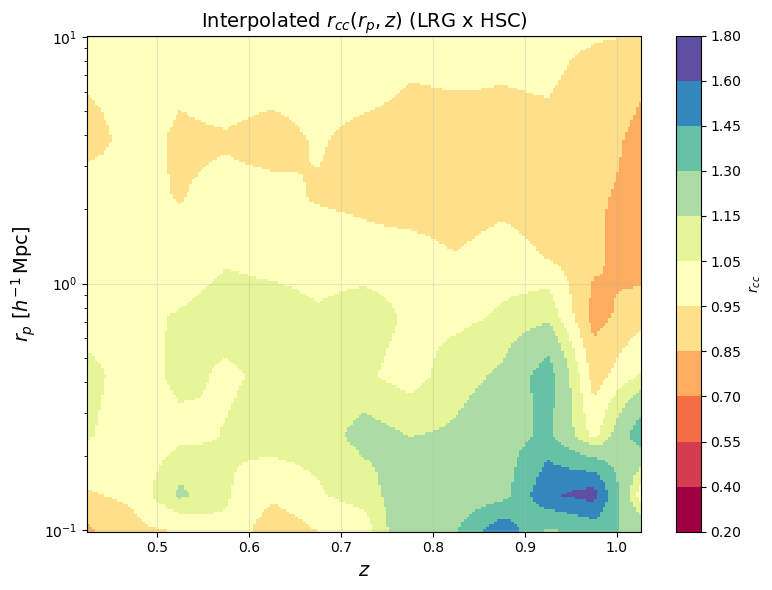

In [138]:
rcc_interp = []
scale_matrix = []

common_scale = np.logspace(-1, 1, 100)  # 0.1 to 10 h⁻¹Mpc (adjust as needed)

for i, r in enumerate(frcc):
    interp = interp1d(scale, r, bounds_error=False, fill_value=np.nan)
    rcc_interp.append(interp(common_scale))

# rcc_interp: shape (n_z, n_common_scale)
# Interpolator expects (z, r_p) in order, so we flip axes
rcc_interp_func = RegularGridInterpolator(
    (zval[:len(frcc)], common_scale),
    rcc_interp,
    bounds_error=False,
    fill_value=np.nan
)

z_fine = np.linspace(min(zval[:len(frcc)]), max(zval[:len(frcc)]), 200)
r_fine = np.logspace(-1, 1, 200)
Z_fine, R_fine = np.meshgrid(z_fine, r_fine)

# Flatten for evaluation
points = np.stack([Z_fine.ravel(), R_fine.ravel()], axis=-1)
rcc_interp_smooth = rcc_interp_func(points).reshape(Z_fine.shape)

levels = [0.2, 0.4, 0.55, 0.7, 0.85, 0.95, 1.05, 1.15, 1.3, 1.45, 1.6, 1.8] #[0.2, 0.4, 0.5, 0.6, 0.75, 0.85, 0.95, 1.05, 1.2]  # 5 intervals = 6 boundaries
vcenter = 1.0

# Step 2: Use a diverging colormap with same number of color bins as level intervals
n_colors = len(levels) - 1
cmap_full = plt.get_cmap('Spectral', 256)  # fine-grained original colormap
colors = cmap_full(np.linspace(0, 1, 256))
i_center = np.argmin(np.abs(np.array(levels) - vcenter))
n_below = i_center
n_above = len(levels) - 1 - i_center
new_colors = cmap_full(np.linspace(0, 1, n_colors))
cmap = mcolors.ListedColormap(new_colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, clip=True)

plt.figure(figsize=(8, 6))
pc = plt.pcolormesh(Z_fine, R_fine, rcc_interp_smooth, cmap=cmap, norm=norm, shading='auto')
plt.yscale('log')
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$r_p$ [$h^{-1}\,\mathrm{Mpc}$]', fontsize=14)
plt.title(r'Interpolated $r_{cc}(r_p, z)$' + f' ({tracer_rcc1} x {tracer_rcc2})', fontsize=14)

cbar = plt.colorbar(pc, ticks=levels, label=r'$r_{cc}$')
cbar.ax.set_yticklabels([f"{lvl:.2f}" for lvl in levels])

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()